In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import pickle

import kind
import utils_data
import utils_plot

In [3]:
# --!--------------------------------------------------------------------------
# --! load trained models

model = torch.load('../../models/kalman/kind_sim.pt', weights_only=False)
model.eval()

model(
  (operator_sta): operator_stationary(
    (enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=20, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=160, bias=True)
          (1): Identity()
        )
      )
    )
    (model): Linear(in_features=6, out_features=6, bias=False)
    (dec_mean): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=6, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=20, bias=True)
          (1): Identity()
        )
      )
    )
    (dec_var): fcnn(
      (

Parameter containing:
tensor([[ 0.1120, -0.2738,  0.6895,  0.3593, -0.1396, -0.0664],
        [ 0.1004, -0.0752, -0.5616,  0.0470,  0.2051,  0.3366],
        [-0.0410,  0.3652,  1.0924, -0.7662, -0.6007, -0.2319],
        [-0.3579, -0.4120,  0.3059, -0.0626, -0.1063, -0.1587],
        [-0.1522, -0.1136, -0.2738,  0.2455,  0.1221,  0.0324],
        [ 0.3680, -0.5284,  0.2886,  0.5575,  0.0618, -0.0270]])


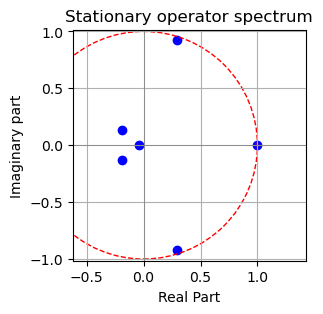

In [4]:
# --!--------------------------------------------------------------------------!
# --! visualize stationary operator eigenvalues

with torch.no_grad():
    utils_plot.plot_eigs(model)

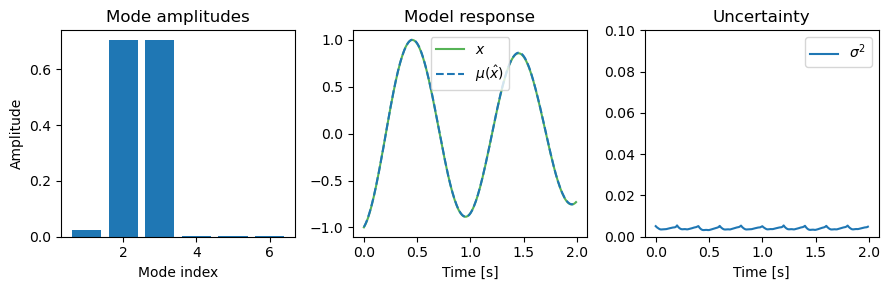

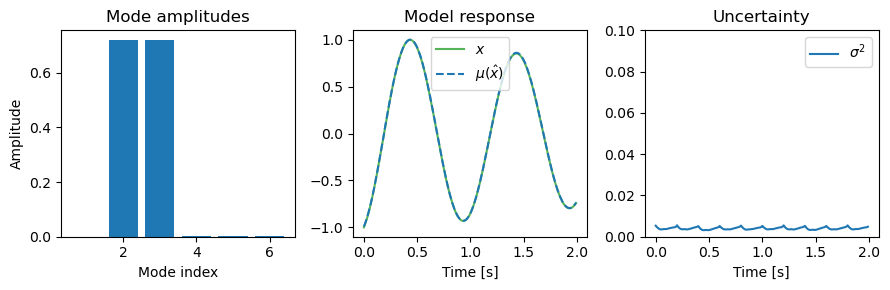

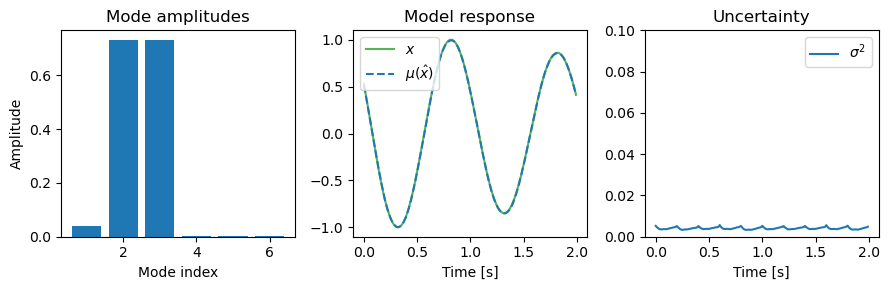

In [5]:
# --!--------------------------------------------------------------------------!
# --! analyze the contribution of stationary operator eigenvalues

datadir            = '../../data/kalman/train_sim_sta'
timeseries_nsample = 200

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

### KIND model test

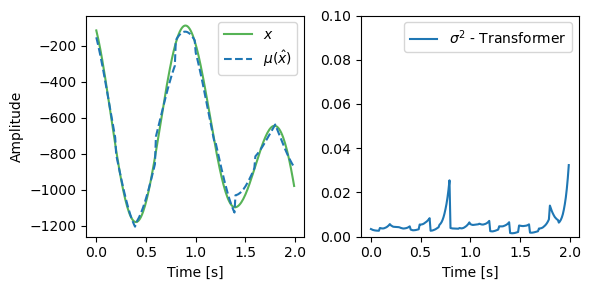

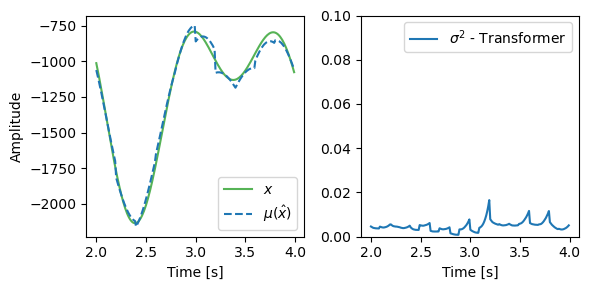

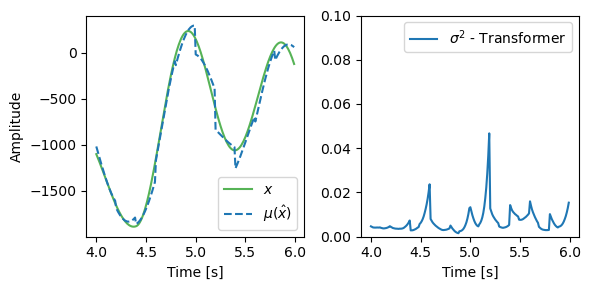

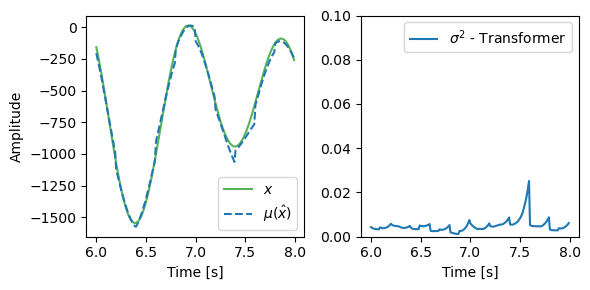

In [6]:
# --!--------------------------------------------------------------------------
# --! evaluate a transient model

with torch.no_grad():
    datadir            = '../../data/kalman/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_transient(model, datadir, timeseries_nsample, datasaved=False)

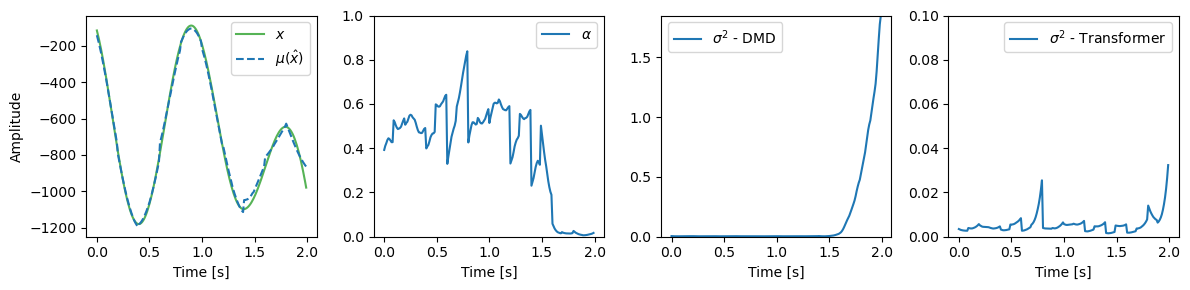

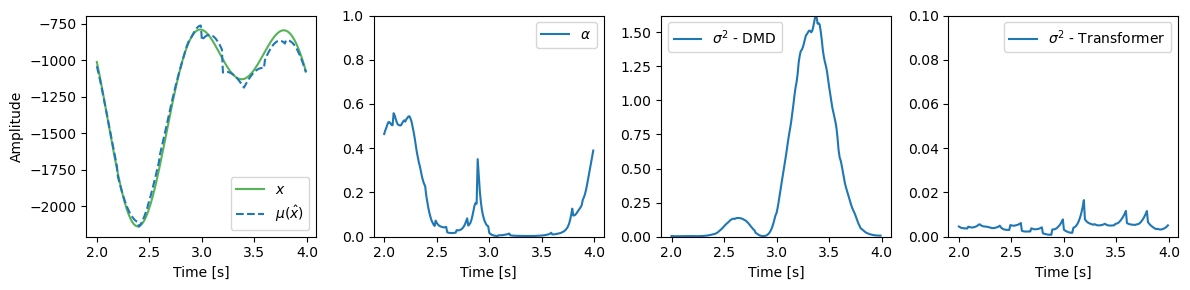

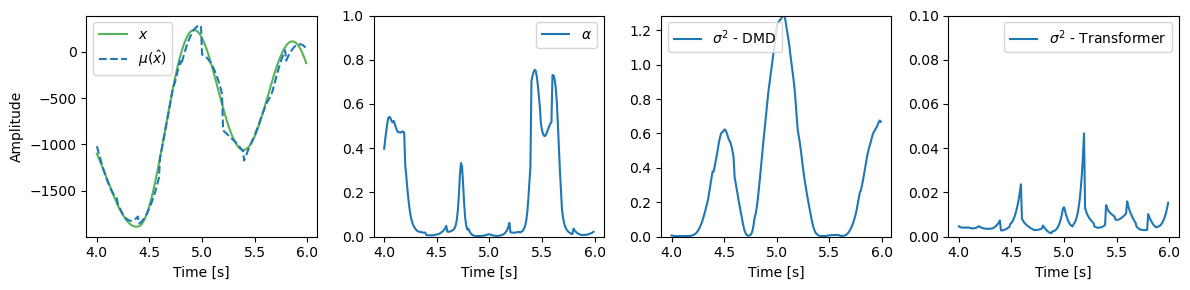

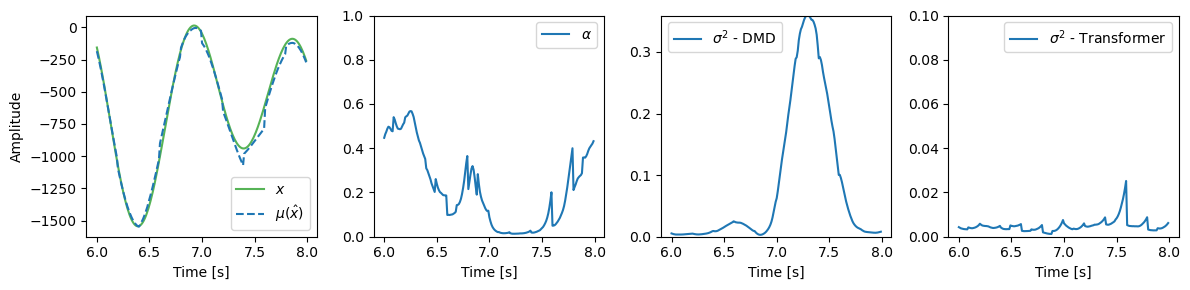

In [7]:
# --!--------------------------------------------------------------------------
# --! test alpha blending

with torch.no_grad():
    datadir            = '../../data/kalman/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_blend(model, datadir, timeseries_nsample, datasaved=False)

In [11]:
def load_object(filename):
    with open(filename, 'rb') as inp:
        return pickle.load(inp)

kf = load_object('../../models/kalman/kf.pkl')

timeseries_nsample = 200
testdata           = utils_data.read_datafile('../../data/kalman/test_sim/eval', timeseries_nsample).detach().numpy()

# --! test data is a batch/array with timeseries, but we want one long timeseries, so reshape
testdata = testdata.reshape(-1, testdata.shape[-1])

kf.x   = np.array([0, 0.])
u      = np.array([[10.]])
kf_pos = []

for j in range(testdata.shape[0]):
    # measurement
    z = testdata[j, 0]

    # Kalman filter step
    kf.predict(u=u)
    kf.update(np.array([z]))

    # store filtered position
    kf_pos.append(kf.x[0])

tensor(555.7419)
(2,)


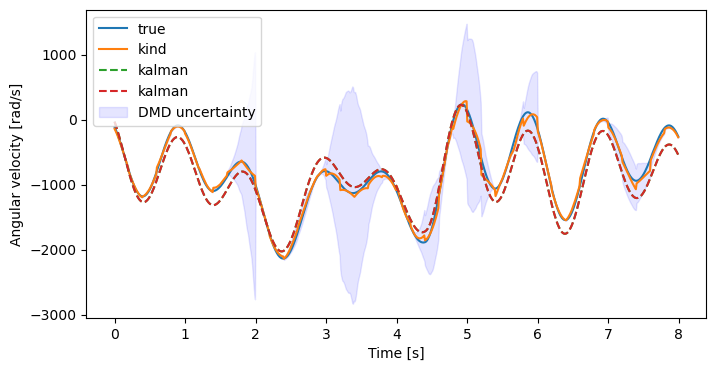

In [21]:
with torch.no_grad():
    datadir            = '../../data/kalman/test_sim'
    timeseries_nsample = 200

    data = utils_data.read_datafile(f'{datadir}/eval', timeseries_nsample)

    # --! data is a batch/array with timeseries, so split it along the batch dimension
    timeseries_bank = torch.split(data, 1, dim=0)

    timeseries_pred_bank = []
    var_sta_bank         = []
    var_trans_bank       = []

    for x in timeseries_bank:
        o = model(x)
        mean         = o[0]
        logvar_sta   = o[2]
        logvar_trans = o[4]

        var_sta      = torch.exp(logvar_sta) + 1e-6
        var_trans    = torch.exp(logvar_trans) + 1e-6

        timeseries_pred_bank.append(mean)
        var_sta_bank.append(var_sta)
        var_trans_bank.append(var_trans)

    timeseries      = torch.cat(timeseries_bank, dim=1)
    timeseries_pred = torch.cat(timeseries_pred_bank, dim=1)
    var_sta         = torch.cat(var_sta_bank, dim=1)
    var_trans       = torch.cat(var_trans_bank, dim=1)

    timeseries      = torch.squeeze(timeseries, 0)
    timeseries_pred = torch.squeeze(timeseries_pred, 0)
    var_sta         = torch.squeeze(var_sta, 0)
    var_trans       = torch.squeeze(var_trans, 0)

    timestep        = model.timestep
    timeseries_dur  = timeseries.shape[0] * timestep
    t = np.arange(0., timeseries_dur, timestep).reshape(-1, 1)

    var_sta_max     = torch.max(var_sta)
    var_trans_max   = torch.max(var_trans)
    var_max         = var_sta_max if var_sta_max > var_trans_max else var_trans_max
    var_scale       = 1/var_max
    var_scale2      = torch.std(timeseries)
    print(var_scale2)
    ci_sta          = var_scale2 * (var_sta / var_scale)
    ci_trans        = var_scale2 * (var_trans / var_scale)

    print(kf_pos[0].shape)
    plt.figure(figsize=(8, 4))
    plt.plot(t, timeseries, label='true')
    plt.plot(t, timeseries_pred, label='kind')
    plt.plot(t, kf_pos, linestyle='dashed', label='kalman')
    plt.fill_between(
        t[:, 0],
        (timeseries_pred-ci_sta)[:, 0], (timeseries_pred+ci_sta)[:, 0], color='blue', alpha=0.1, label='DMD uncertainty')
    #plt.fill_between(
        #t[:, 0],
        #(timeseries_pred-ci_trans)[:, 0], (timeseries_pred+ci_trans)[:, 0], color='green', alpha=0.25, label='Transformer uncertainty')
    plt.legend()
    plt.xlabel('Time [s]')
    plt.ylabel('Angular velocity [rad/s]')
    plt.show()